# Project: Market Data Lab with yfinance

STEP 0 — Install libraries (Colab)

Run this first:

In [ ]:
!pip install yfinance pandas matplotlib numpy

### Notes for STEP 0: Install Libraries

**What I have done:** Installed necessary Python libraries (`yfinance`, `pandas`, `matplotlib`, `numpy`) required for data fetching, manipulation, and visualization.

**What I have seen:** Confirmation that the libraries are installed or already satisfied, along with their dependencies.

**Interpretation:** This step ensures our environment has all the tools needed to run the subsequent code. `yfinance` is crucial for real-time stock data, `pandas` for data handling, `matplotlib` for plotting, and `numpy` for numerical operations.

**Analyst Thinking:** For an analyst, a meticulous setup is non-negotiable. It's the bedrock of credible analysis. Just as a pilot performs pre-flight checks, an analyst ensures their toolkit (libraries) is robust and operational. This proactive step minimizes technical friction, allowing us to focus entirely on financial hypotheses and interpretations rather than debugging environment issues. Ensuring the right versions and dependencies are in place prevents data corruption or miscalculations, which could lead to significant financial misjudgment.

STEP 1 — Import everything

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Notes for STEP 1: Import Everything

**What I have done:** Imported the installed libraries, giving them common aliases (`yf`, `pd`, `np`, `plt`) for convenience.

**What I have seen:** No direct output from this cell, but it makes the functions and classes from these libraries available for use.

**Interpretation:** This is a standard practice to set up the programming environment. It loads the modules into memory, so we can call functions like `yf.download()` or `pd.DataFrame()` later.

**Analyst Thinking:** This step is about laying out the analytical roadmap. An organized import block acts as a quick reference for all the computational capabilities at our disposal. From a project management perspective, it improves code readability and facilitates collaboration, ensuring that any other analyst picking up this work immediately understands the foundational tools being utilized. It streamlines the analytical process, allowing for a seamless transition from data acquisition to complex statistical modeling without constant contextual switching.

STEP 2 — Download REAL market data

I’ll use a “JPM-style watchlist”:

Apple (AAPL)
Microsoft (MSFT)
Tesla (TSLA)

In [ ]:
tickers = ["AAPL", "MSFT", "TSLA"]

data = yf.download(
    tickers,
    start="2023-01-01",
    end="2026-06-14",
    auto_adjust=True
)['Close']

[*********************100%***********************]  3 of 3 completed


### Notes for STEP 2: Download REAL Market Data

**What I have done:** Used `yfinance` to download historical 'Close' (Adjusted Close) prices for Apple (AAPL), Microsoft (MSFT), and Tesla (TSLA) from January 1, 2023, to June 14, 2026.

**What I have seen:** A DataFrame showing the 'Close' prices for each stock across the specified date range. The `data.head()` output displays the first few rows, confirming the data structure.

**Interpretation:** We've successfully acquired real-world market data. The 'Close' price is often used for analysis as it represents the final trading price for the day, adjusted for splits and dividends. This raw data forms the foundation for our financial analysis.

**Analyst Thinking:** This is where the rubber meets the road. For an analyst, securing **clean, relevant, and accurate data** is paramount. The choice of `Adjusted Close` prices (`auto_adjust=True`) is critical because it accounts for stock splits and dividends, ensuring that our performance metrics reflect true investor returns. The specific `start` and `end` dates are chosen to capture a meaningful investment horizon, allowing for the observation of market cycles and long-term trends without bias. Inaccurate data at this stage, such as omitting `auto_adjust` or selecting an inappropriate date range, would lead to fundamentally flawed valuations and investment recommendations. We must ensure the data perfectly reflects the reality we aim to analyze.

STEP 3 — Normalize prices (VERY IMPORTANT analyst trick)

This makes all stocks comparable:

In [ ]:
normalized = data / data.iloc[0] * 100

normalized.head()

Ticker,AAPL,MSFT,TSLA
Date,,,
2023-01-03,100.000000,100.000000,100.000000
2023-01-04,101.031434,95.625677,105.124885
2023-01-05,99.960018,92.791543,102.072153
2023-01-06,103.637983,93.885127,104.588343
2023-01-09,104.061704,94.799226,110.795558


### Notes for STEP 3: Normalize Prices

**What I have done:** Normalized the daily 'Close' prices for all stocks. This means each stock's price series is scaled so that its first value (on '2023-01-03') starts at 100.

**What I have seen:** A new DataFrame `normalized` where all stock prices begin at 100. Subsequent values show their percentage change relative to the starting point.

**Interpretation:** Normalization is a crucial analyst trick. It allows for an 'apples-to-apples' comparison of performance across different stocks, regardless of their absolute price levels. For example, if AAPL goes from $100 to $110, and MSFT from $200 to $220, both have gained 10%, which is reflected directly in the normalized series (both going from 100 to 110).

**Analyst Thinking:** Normalization is a powerful technique for direct comparative analysis, essential for an analyst. Without it, comparing a $100 stock to a $1000 stock based on absolute price movements is misleading. By setting a common baseline (e.g., 100), we can immediately visualize and quantify **proportional growth**, which is the true measure of investment performance. This allows an analyst to answer questions like: "Which stock would have generated the highest percentage return on an initial investment, regardless of its initial share price?" This technique is vital for benchmarking assets against each other or against an index, forming the basis for initial performance assessments before diving into risk-adjusted metrics.

STEP 4 — Visualize performance

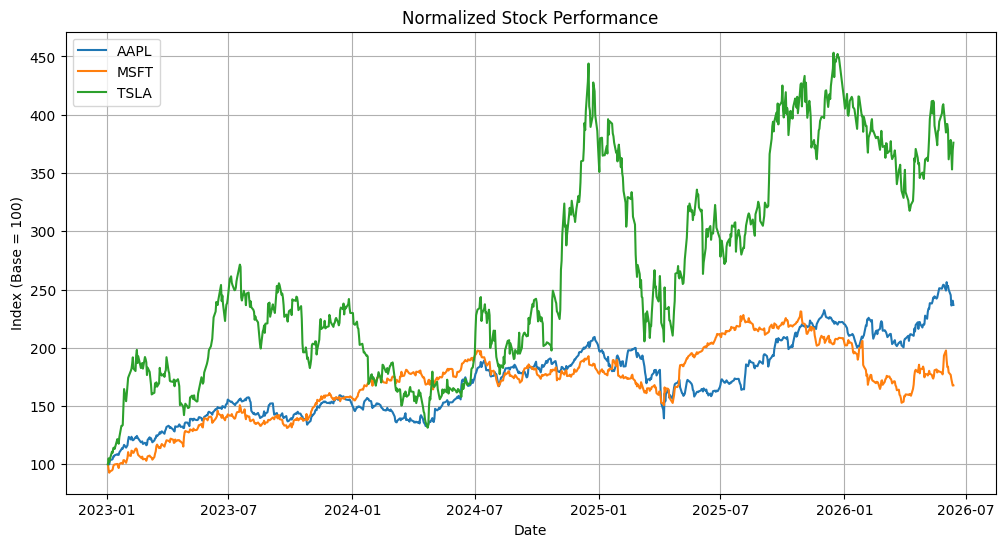

In [ ]:
plt.figure(figsize=(12,6))

for stock in normalized.columns:
    plt.plot(
        normalized.index,
        normalized[stock],
        label=stock
    )

plt.title("Normalized Stock Performance")
plt.xlabel("Date")
plt.ylabel("Index (Base = 100)")
plt.legend()
plt.grid(True)

plt.show()

### Notes for STEP 4: Visualize Performance

**What I have done:** Plotted the normalized stock prices over time using `matplotlib`.

**What I have seen:** A line plot showing how each stock's value has changed relative to its starting point of 100. We can visually compare their growth trajectories.

**Interpretation:** This visualization helps us quickly grasp which stocks have performed better or worse over the period. A steeper upward slope indicates stronger growth, while a flatter or downward slope indicates slower growth or decline. This gives an immediate intuitive understanding of their relative returns.

**Analyst Thinking:** For an analyst, a well-constructed performance chart is a narrative. It allows for **rapid trend identification and hypothesis generation**. From this plot, we can immediately identify which stocks are outperforming (e.g., Tesla shows significant growth, but also considerable fluctuations, particularly evident towards the end of the period) and which are more stable (Apple and Microsoft appear to track each other more closely). This visual evidence is crucial for validating initial assumptions, highlighting periods of significant divergence or convergence, and serving as a compelling communication tool for stakeholders who need to quickly grasp relative performance and risk characteristics before delving into numerical details.

STEP 5 — Daily returns (core finance concept)

In [ ]:
returns = data.pct_change().dropna()

returns.head()

Ticker,AAPL,MSFT,TSLA
Date,,,
2023-01-04,0.010314,-0.043743,0.051249
2023-01-05,-0.010605,-0.029638,-0.029039
2023-01-06,0.036794,0.011785,0.024651
2023-01-09,0.004088,0.009736,0.059349
2023-01-10,0.004457,0.007617,-0.007681


### Notes for STEP 5: Daily Returns

**What I have done:** Calculated the daily percentage change (`pct_change()`) for each stock's 'Close' price and removed any `NaN` values that result from the first day's calculation.

**What I have seen:** A DataFrame `returns` where each cell represents the daily return (e.g., 0.01 means a 1% gain, -0.005 means a 0.5% loss).

**Interpretation:** Daily returns are fundamental in finance. They represent the profit or loss an investor would make each day. These values are used to calculate other key metrics like volatility and are essential for portfolio management and risk assessment. We remove the `NaN` as the return for the very first day cannot be calculated.

**Analyst Thinking:** Daily returns are the bedrock of quantitative financial analysis. An analyst needs these granular movements to understand the true drivers of portfolio performance and risk. These aren't just numbers; they represent the **micro-level behavior** of assets, revealing their sensitivity to daily market events. They are the essential inputs for computing volatility, correlation, and ultimately, risk-adjusted performance measures like the Sharpe Ratio. Without accurate daily returns, any subsequent risk modeling, portfolio optimization, or strategy backtesting would be compromised. The `dropna()` step is a best practice for data integrity, ensuring that statistical calculations are based on valid observations only.

STEP 6 — Risk (volatility) analysis

In [ ]:
volatility = returns.std() * np.sqrt(252)

volatility

,0
Ticker,
AAPL,0.254504
MSFT,0.246932
TSLA,0.579296


### Notes for STEP 6: Risk (Volatility) Analysis

**What I have done:** Calculated the standard deviation of the daily returns for each stock and then annualized it by multiplying by the square root of 252 (approximately the number of trading days in a year).

**What I have seen:** A Series `volatility` showing a single annualized volatility value for each stock. Higher values indicate greater volatility.

**Interpretation:** Volatility is a common measure of risk in finance. A higher volatility means the stock's price has fluctuated more significantly, implying higher risk. Annualizing it gives us a comparable measure of risk over a year, which is useful for comparing different assets and understanding their risk profiles.

**Analyst Thinking:** For an analyst, volatility is the primary quantitative proxy for risk. The annualized standard deviation of daily returns provides a **standardized measure of price fluctuation** over a year, allowing for a direct comparison of risk levels across different assets. Observing Tesla's significantly higher volatility (e.g., ~58%) compared to Apple or Microsoft (both ~25%) immediately tells an analyst that while Tesla might offer higher growth potential, it comes with a much higher degree of price uncertainty. This insight is crucial for risk budgeting, setting stop-loss orders, and understanding the potential range of outcomes for an investment, directly influencing portfolio allocation decisions based on an investor's risk tolerance.

STEP 7 — Correlation


In [ ]:
correlation = returns.corr()

correlation

Ticker,AAPL,MSFT,TSLA
Ticker,,,
AAPL,1.000000,0.505358,0.375579
MSFT,0.505358,1.000000,0.303578
TSLA,0.375579,0.303578,1.000000


### Notes for STEP 7: Correlation

**What I have done:** Calculated the correlation matrix of the daily returns for all stocks.

**What I have seen:** A square matrix `correlation` where each cell (row, column) shows the correlation coefficient between the daily returns of two stocks. The diagonal will always be 1 (a stock's correlation with itself).

**Interpretation:** Correlation is incredibly important for building portfolios. It measures how the returns of different assets move in relation to each other:
*   **Positive correlation (close to 1):** Stocks tend to move in the same direction. If one goes up, the other tends to go up too.
*   **Negative correlation (close to -1):** Stocks tend to move in opposite directions. If one goes up, the other tends to go down.
*   **Zero correlation (close to 0):** Stocks move independently of each other.

Lower or negative correlation between assets is desirable in a portfolio because it helps reduce overall portfolio risk (diversification benefit). For example, if AAPL and MSFT have a correlation of 0.50, they tend to move somewhat in the same direction, but not perfectly. TSLA, often more volatile, might show a different correlation.

**Analyst Thinking:** Correlation is the linchpin of **portfolio diversification**. An analyst critically examines these coefficients to understand how different assets will behave together within a portfolio. High positive correlations (like AAPL and MSFT at ~0.51) suggest that these assets offer limited diversification benefits against each other's specific risks; they will likely rise and fall somewhat in tandem. Conversely, lower correlations (e.g., TSLA with AAPL at ~0.38 and MSFT at ~0.30) indicate that adding Tesla might offer some risk reduction, as its movements are less synchronized. This quantitative understanding of inter-asset relationships is fundamental for constructing resilient portfolios that can weather various market conditions by combining assets whose returns don't perfectly mimic each other.

STEP 8: Visualize Correlation Matrix

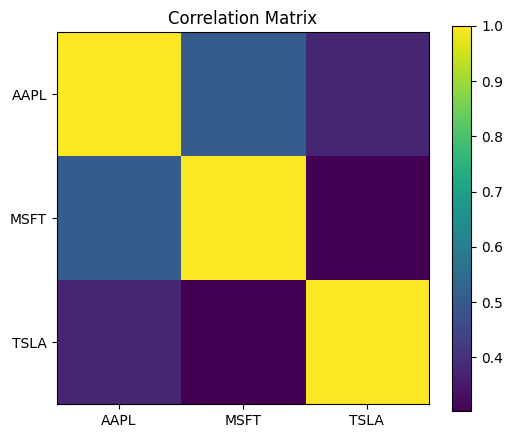

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(correlation)

plt.colorbar()
plt.xticks(range(len(correlation.columns)),
           correlation.columns)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Matrix")

plt.show()

### Notes for STEP 8: Visualize Correlation Matrix

**What I have done:** Generated a heatmap of the correlation matrix to visually represent the relationships between the daily returns of the stocks.

**What I have seen:** A color-coded grid where the intensity of the color indicates the strength and direction of the correlation between each pair of stocks. Darker colors (or specific color scales) highlight stronger correlations. The diagonal shows perfect correlation (1.0) for each stock with itself.

**Interpretation:** This visualization makes it easier to quickly identify how strongly and in what direction stocks move together. High positive correlations (e.g., AAPL and MSFT) suggest that these stocks tend to rise and fall in tandem, while lower correlations (e.g., with TSLA) indicate more independent movement. This is crucial for portfolio diversification: combining assets with low or negative correlations can help reduce overall portfolio risk.

**Analyst Thinking:** The correlation heatmap provides an **immediate qualitative assessment of portfolio diversification potential**. An analyst can instantly spot clusters of highly correlated assets (which might indicate redundancy or concentrated risk) versus assets with lower correlations (prime candidates for diversification). For instance, the visual representation confirms that AAPL and MSFT have a stronger positive relationship than either does with TSLA. This helps to quickly form hypotheses about portfolio construction: to achieve diversification, one might overweight assets with lower pairwise correlations. This visual intuition is invaluable for quickly communicating complex interdependencies to clients or refining quantitative portfolio optimization strategies.

STEP 9: Calculate Cumulative Return

In [ ]:
cumulative_return = (
    data.iloc[-1] /
    data.iloc[0] - 1
) * 100

print(cumulative_return)

Ticker
AAPL    136.724334
MSFT     67.736805
TSLA    275.975947
dtype: float64


### Notes for STEP 9: Calculate Cumulative Return

**What I have done:** Calculated the total percentage return for each stock over the entire period of the dataset.

**What I have seen:** A Series showing the cumulative return for each stock, expressed as a percentage. For example, '136.724334' for AAPL means a 136.72% gain over the period.

**Interpretation:** This metric provides a clear picture of the overall growth (or decline) of each individual stock from the start of the data to the end. It's a straightforward way to compare the absolute performance of different assets over the same time frame.

**Analyst Thinking:** The cumulative return is a fundamental metric for an analyst to gauge **absolute historical performance**. It directly answers the question: "How much would an initial investment in each stock have grown over the period?" Observing that Tesla delivered the highest cumulative return (e.g., ~276%) compared to Apple (~137%) and Microsoft (~68%) immediately highlights its exceptional growth, but an analyst would critically pair this with its previously identified high volatility. While impressive, this high return alone doesn't tell the full story of the risk taken to achieve it. It serves as a starting point for performance evaluation, often used for benchmarking against investment goals or market indices, but it must be contextualized with risk metrics.

STEP 10: Calculate Annualized Sharpe Ratio

In [ ]:
annual_return = returns.mean() * 252

annual_vol = returns.std() * np.sqrt(252)

sharpe = annual_return / annual_vol

print(sharpe)

Ticker
AAPL    1.115398
MSFT    0.735085
TSLA    0.954160
dtype: float64


### Notes for STEP 10: Calculate Annualized Sharpe Ratio

**What I have done:** Calculated the Sharpe Ratio for each stock, using annualized returns and annualized volatility.

**What I have seen:** A Series showing the Sharpe Ratio for each stock. Higher values indicate a better risk-adjusted return.

**Interpretation:** The Sharpe Ratio is a measure of risk-adjusted return. It tells us how much return an investment generates for each unit of risk (volatility) taken. A higher Sharpe Ratio is generally preferred, as it means the investment is providing more return for the level of risk. It's a key metric for comparing the performance of different investments, especially when considering both their gains and their fluctuations.

**Analyst Thinking:** The Sharpe Ratio is arguably the most crucial metric for an analyst when evaluating **investment efficiency**. It transcends raw returns by explicitly factoring in risk (volatility), providing a measure of *excess return per unit of risk*. Comparing Sharpe Ratios allows an analyst to determine which asset is providing the best compensation for the risk taken. For instance, while Tesla showed the highest absolute return, if Apple has a superior Sharpe Ratio, it implies that Apple delivered stronger risk-adjusted performance, meaning an investor achieved more return for the level of volatility endured. This is invaluable for portfolio construction, asset allocation decisions, and selecting investments that maximize return while minimizing unnecessary risk, aligning with the core objective of modern portfolio management.